# Delta-Base Planning from Differentiable Flowsheets

Refinery and value-chain planning has been done for decades with linear programs whose unit
submodels are *base plus delta vectors* — a first-order Taylor expansion
$y \approx y_0 + J\,(u - u_0)$. Aspen PIMS, Haverly GRTMPS, Honeywell RPMS and AVEVA Spiral
Plan all work this way; the refereed anchor is Baker and Lasdon, *Successive Linear
Programming at Exxon*, Management Science **31**(3), 1985.

In all of those systems the delta vectors are built by **perturbing a rigorous simulator one
variable at a time**, which costs $O(n)$ model evaluations and is why they are refreshed on
the order of annually.

A difflow flowsheet is a pure function with its flash, recycle and unit solves embedded, so
`jax.jacobian` returns the *reduced* input–output sensitivity directly — already implicitly
differentiated through those inner solves. **That reduced Jacobian is the delta vector**, and
it costs $O(1)$.

This notebook works a two-plant chain end to end:

1. build the blocks and the network,
2. check the delta vectors and measure what they cost,
3. plan, and watch an allocation lever switch corner with prices,
4. read off the sensitivity of the *plan itself*,
5. see what the trust-region acceptance test is for,
6. see the phase-boundary diagnostic,
7. emit the Pyomo model.

In [1]:
import warnings

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from difflow.planning import (
    Block, Network, DeltaBasePlanner, PiecewiseSpec, PhaseBoundaryWarning,
    check_delta_vectors, choose_ad_mode, linearize_block, planner_objective,
    price_switch_point, scaling_study, format_scaling_table,
)
from difflow.planning import chain as chain_mod

plt.rcParams.update({"figure.figsize": (7.0, 4.0), "figure.dpi": 110})

## 1. The chain

Two plants, coupled through the residue stream:

* **NGL recovery** — a real cryogenic flash (`difflow.units.flash.Flash`, with a
  Rachford–Rice root find inside it) plus a cold-reflux lever and an ethane
  recovery-versus-rejection lever. Four decisions.
* **Gas-turbine power** — burns the residue gas, with a part-load efficiency curve and an
  allocation lever choosing between burning the residue and selling it. One decision.

`ngl.residue_F → power.fuel_F` is a **link**: the downstream plant's inlet is whatever the
upstream plant produces, so it is not a free decision.

The model ships as `difflow.planning.chain` so the notebook, the docs and the regression
tests all describe the same problem. Its thermodynamics are ideal and the flowsheet is
schematic — it is a faithful *shape* of a planning problem, not a plant design.

In [2]:
problem = chain_mod.two_plant_chain()
net = problem.network

print(net)
print("evaluation order  :", net.order)
print("free decisions    :", net.decision_names)
print("linked inlet      :", [l.target for l in net.links])
print("specs             :", problem.specs)

Network(blocks=['ngl', 'power'], links=1, n_decisions=5)
evaluation order  : ['ngl', 'power']
free decisions    : ['ngl.ethane_recovery', 'ngl.T_coldbox', 'ngl.split', 'ngl.P_expander', 'power.alloc']
linked inlet      : ['power.fuel_F']
specs             : [Spec(ngl.T_colfeed <= 236)]


In [3]:
state = net.evaluate(net.decision_start())
for name, value in state.as_dict().items():
    print(f"  {name:<24s} {value:12.5g}")

  ngl.ethane_recovery               0.7
  ngl.T_coldbox                     232
  ngl.split                         0.4
  ngl.P_expander                3.2e+06
  ngl.NGL_C2                     6.8516
  ngl.NGL_C3plus                 12.712
  ngl.residue_F                  80.436
  ngl.E_refrig                   1.7987
  ngl.T_colfeed                   241.6
  power.fuel_F                   80.436
  power.alloc                       0.5
  power.Power                    18.058
  power.CO2                      1.9305
  power.gas_sold                 40.218


## 2. Delta vectors

A delta vector is one AD pass per block. Two things are worth checking before trusting one.

**Does it agree with the perturbation it replaces?** `check_delta_vectors` runs central
differences — the $2n$-evaluation method — and compares.

In [4]:
ngl = chain_mod.ngl_block()
check = check_delta_vectors(ngl, rtol=1e-4)
print(f"AD mode                : {check['mode']}")
print(f"max relative error     : {check['max_rel_error']:.3e}")
print(f"passes at rtol = 1e-4  : {check['passed']}")

AD mode                : fwd
max relative error     : 8.230e-11
passes at rtol = 1e-4  : True


**Which AD mode?** Reverse mode builds the Jacobian one *output* at a time and forward mode
one *input* at a time, so the cheaper mode is the one with fewer of them. The planner picks
by shape rather than hard-coding either.

In [5]:
print("80 decisions, scalar objective :", choose_ad_mode(n_u=80, n_y=1))
print("1 lever, 40 reported outputs   :", choose_ad_mode(n_u=1,  n_y=40))
print("the NGL block (4 in, 5 out)    :", linearize_block(ngl).mode)

80 decisions, scalar objective : rev
1 lever, 40 reported outputs   : fwd
the NGL block (4 in, 5 out)    : fwd


In [6]:
lin = linearize_block(ngl)
print(lin.as_table(ngl.u_names, ngl.y_names))

delta vectors for block 'ngl'
                    ethane_recovery        T_coldbox            split       P_expander
NGL_C2                        9.788          -0.1783           0.2603        2.223e-06
NGL_C3plus                        0          -0.0429           0.1578        4.947e-07
residue_F                    -9.788           0.2212          -0.4181       -2.718e-06
E_refrig                         -0           -0.026               -0       -2.812e-08
T_colfeed                         6                1              -14                0


Read the first column: raising ethane recovery by one unit adds 6.7 mol/s of ethane product
and takes 6.7 mol/s straight out of the residue gas. That trade is the whole plan.

## 3. What the delta vectors cost

The argument for AD is asymptotic, so measure it. A planning horizon is how $n$ gets large:
each period adds five decisions, so $n = 5H$.

In [7]:
def make_problem(n):
    prob = chain_mod.two_plant_chain(horizon=n // 5)
    return planner_objective(prob.planner()), prob.network.decision_start()

rows = scaling_study(make_problem, [5, 10, 20, 40, 80], repeats=3, mode="rev")
print(format_scaling_table(rows))

| n | one eval | AD gradient | FD gradient | AD / eval | FD / eval | speedup |
|---|---|---|---|---|---|---|
| 5 | 1.46e-05 s | 1.99e-05 s | 0.00411 s | 1.4x | 281x | 207x |
| 10 | 1.75e-05 s | 2.76e-05 s | 0.0079 s | 1.6x | 452x | 286x |
| 20 | 7.29e-05 s | 5.18e-05 s | 0.0188 s | 0.7x | 258x | 363x |
| 40 | 9.61e-05 s | 0.000125 s | 0.0376 s | 1.3x | 391x | 300x |
| 80 | 0.000513 s | 0.000542 s | 0.13 s | 1.1x | 254x | 241x |


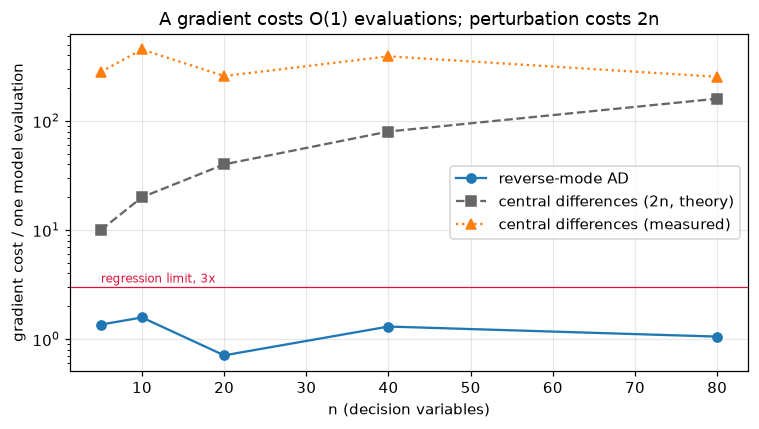

In [8]:
ns = [r.n for r in rows]
fig, ax = plt.subplots()
ax.plot(ns, [r.ad_ratio for r in rows], "o-", label="reverse-mode AD")
ax.plot(ns, [2 * n for n in ns], "s--", color="0.4", label="central differences (2n, theory)")
ax.plot(ns, [r.fd_ratio for r in rows], "^:", label="central differences (measured)")
ax.set(xlabel="n (decision variables)", ylabel="gradient cost / one model evaluation",
       yscale="log", title="A gradient costs O(1) evaluations; perturbation costs 2n")
ax.axhline(3.0, color="crimson", lw=0.8)
ax.text(ns[0], 3.3, "regression limit, 3x", color="crimson", fontsize=8)
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()

The AD gradient stays a small constant multiple of one evaluation across the whole sweep,
with no trend in $n$. It can sit *below* one: on a compiled model XLA prunes parts of the
forward program the gradient does not need, so the two are not strictly nested. The measured
finite-difference cost runs *above* the $2n$ line because each of the $2n$ calls also pays
Python dispatch on a sub-millisecond model; on a slower rigorous simulator the two lines
converge. Either way the gap grows linearly, and planning is where $n$ grows.

## 4. Planning, and a lever that switches

Prices are linear in the block outputs — that is what keeps the model an LP. The
deethanizer feed temperature carries an upper spec.

In [9]:
warnings.simplefilter("ignore", PhaseBoundaryWarning)   # section 7 looks at these

planner = problem.planner(radius=0.25)
result = planner.solve()
print(result.summary())

Plan (converged, stationary, 3 iterations, 9 start(s))
  objective             2470.47
  merit                 2470.47   (objective less realised-violation charge)
  violation                   0   (from the nonlinear model, not the LP)
  final radius              0.5
  decisions:
    ngl.ethane_recovery                         0.3
    ngl.T_coldbox                             237.2
    ngl.split                                     1
    ngl.P_expander                          2.5e+06
    power.alloc                                   1


`alloc = 1` and `ethane_recovery` at its *lower* bound: at a power price of \$55/MW the
residue gas is worth more burned than sold, and ethane is worth more rejected into that
residue than recovered as product. Both levers are at a bound — they are bang-bang.

Bang-bang levers do not slide with price, they *switch*. Sweep the power price and watch.

In [10]:
power_prices = np.linspace(5.0, 60.0, 12)
sweep = []
for price in power_prices:
    p = problem.planner(radius=0.25)
    p.prices = dict(problem.prices)
    p.prices["power.Power"] = float(price)
    r = p.solve()
    sweep.append((r.plan["power.alloc"], r.plan["ngl.ethane_recovery"], r.objective))

alloc, recovery, profit = map(np.array, zip(*sweep))

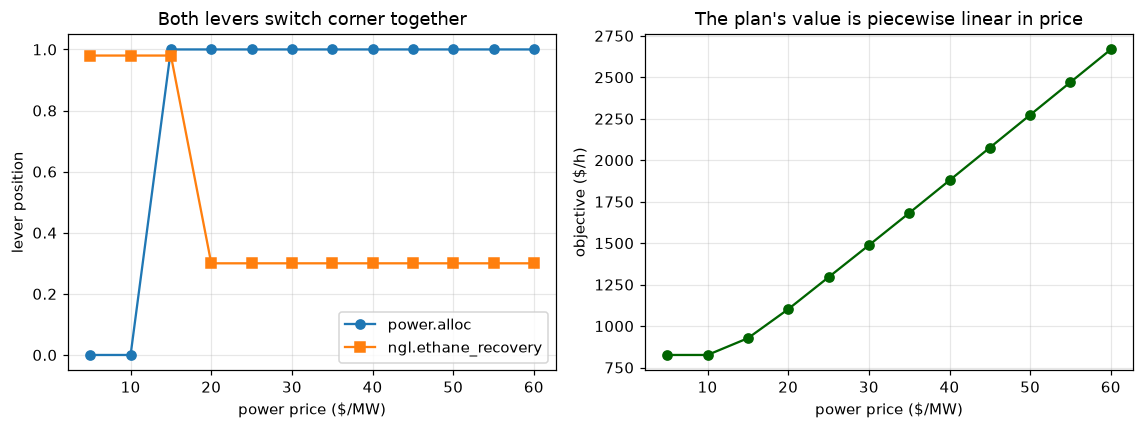

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
ax1.plot(power_prices, alloc, "o-", label="power.alloc")
ax1.plot(power_prices, recovery, "s-", label="ngl.ethane_recovery")
ax1.set(xlabel="power price ($/MW)", ylabel="lever position",
        title="Both levers switch corner together")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(power_prices, profit, "o-", color="darkgreen")
ax2.set(xlabel="power price ($/MW)", ylabel="objective ($/h)",
        title="The plan's value is piecewise linear in price")
ax2.grid(alpha=0.3)
fig.tight_layout()

A single interior start would decide that corner by whichever way the local slope happened to
point. The planner also seeds from bound vertices of the most price-sensitive decisions —
ranked with one reverse-mode AD pass, whatever $n$ is.

In [12]:
seeds = planner.vertex_seeds()
print(f"{len(seeds)} vertex seeds, on top of the nominal start")
print("decision names:", net.decision_names)
for s in seeds[:4]:
    print("  ", np.array2string(s, precision=4, suppress_small=True))
print(f"\nthe winning run used {result.n_starts} starts in total")

8 vertex seeds, on top of the nominal start
decision names: ['ngl.ethane_recovery', 'ngl.T_coldbox', 'ngl.split', 'ngl.P_expander', 'power.alloc']
   [      0.3     218.        0.4 3200000.        0. ]
   [      0.3     244.        0.4 3200000.        0. ]
   [      0.98     218.         0.4  3200000.         0.  ]
   [      0.98     244.         0.4  3200000.         0.  ]

the winning run used 9 starts in total


The useful question about a bang-bang lever is not its derivative — which is zero — but
where it flips. `price_switch_point` bisects for it.

In [13]:
switch = price_switch_point(problem.planner(radius=0.25), "power.Power", 5.0, 60.0,
                            decision="power.alloc", tol=0.05)
print(f"power.alloc switches at a power price of ${switch['price']:.2f}/MW")
print(f"  below: alloc = {switch['plan_low']['power.alloc']:.3f}"
      f"   above: alloc = {switch['plan_high']['power.alloc']:.3f}")

power.alloc switches at a power price of $12.08/MW
  below: alloc = 0.000   above: alloc = 1.000


## 5. The sensitivity of the plan, not just the plan

Because the blocks are differentiable, the converged plan can itself be differentiated:
$\mathrm{d}(\text{plan})/\mathrm{d}(\text{price})$,
$\mathrm{d}(\text{profit}^*)/\mathrm{d}(\text{parameter})$. This is what k_aug and sIPOPT
give for a single NLP, obtained here by the implicit function theorem on the KKT conditions
at the plan. A planning system whose submodels are not differentiable structurally cannot
provide it.

Take a price *inside* the switch, where the plan has an interior degree of freedom left.

In [14]:
mid = problem.planner(radius=0.25)
mid.prices = dict(problem.prices)
mid.prices["power.Power"] = 30.0
mid_result = mid.solve()
sens = mid_result.plan_sensitivity(wrt="prices")
print(sens.summary())

Plan sensitivity w.r.t. prices
  at a bound (d(plan)/d(param) = 0): ngl.ethane_recovery, ngl.split, ngl.P_expander, power.alloc
  active constraints: T_colfeed
  d(objective)/d(param):
    ngl.NGL_C2                              3.28583
    ngl.NGL_C3plus                          12.9024
    ngl.E_refrig                             1.6434
    power.Power                             38.5534
    power.gas_sold                                0
    power.CO2                               4.02296


Levers pinned at a bound report exactly zero and say so, rather than letting a vertex be read
as an interior solution. The objective row is the envelope theorem and is exact regardless:
$\mathrm{d}(\text{profit}^*)/\mathrm{d}c_k$ is the activity level of the thing priced at
$c_k$.

The same machinery works against **model or design parameters**, which is what makes capital
planning tractable without enumerating scenarios.

In [15]:
theta_sens = mid_result.plan_sensitivity(wrt="theta",
                                         params=["power.F_design", "power.w_net"])
print(theta_sens.summary())

Plan sensitivity w.r.t. theta
  at a bound (d(plan)/d(param) = 0): ngl.ethane_recovery, ngl.split, ngl.P_expander, power.alloc
  active constraints: T_colfeed
  d(objective)/d(param):
    power.F_design                                0
    power.w_net                          0.00251435


## 6. Why the trust region has an acceptance test

Each cycle linearises, solves the LP, and then **evaluates the caller's own nonlinear blocks
at the proposal**, accepting only on realised improvement. Without that step — the
"recursion" heuristic — repeated re-linearisation walks the iterate outside where any Taylor
model is valid.

The theory is Eason and Biegler (AIChE J 62(9), 2016, doi:10.1002/aic.15325). Their
first-order consistency requirement is met *exactly* by an AD Taylor model, not just to
truncation error, which is why this loop can claim convergence where "recursion" cannot.

Here is the difference on a block with a known optimum at $(0.3,\,0.7)$.

In [16]:
from difflow.planning import TrustRegionOptions

bowl = Block(name="q", fn=lambda u: jnp.array([-(u[0] - 0.3) ** 2 - (u[1] - 0.7) ** 2]),
             u_names=["x", "y"], y_names=["f"], lb=[0.0, 0.0], ub=[1.0, 1.0])
bowl_net = Network([bowl])

guarded = DeltaBasePlanner(bowl_net, prices={"q.f": 1.0}, radius=0.3).solve()
unguarded = DeltaBasePlanner(bowl_net, prices={"q.f": 1.0}, radius=0.3,
                             accept_test=False, vertex_seeding=False,
                             options=TrustRegionOptions(radius=0.3, max_iter=40)).solve()

print(f"with acceptance test : converged={guarded.converged}  "
      f"plan={np.round(guarded.decisions, 6)}")
print(f"without              : converged={unguarded.converged}  "
      f"plan={np.round(unguarded.decisions, 6)}")
print(f"\nrho on the first six unguarded steps: "
      f"{[round(h.rho, 3) for h in unguarded.history[:6]]}")
print("(rho < 0 means the nonlinear model got *worse* where the LP promised better)")

with acceptance test : converged=True  plan=[0.3 0.7]
without              : converged=False  plan=[0.5 0.5]

rho on the first six unguarded steps: [0.25, -0.5, 0.25, -0.5, 0.25, -0.5]
(rho < 0 means the nonlinear model got *worse* where the LP promised better)


A second trap sits next to this one. Elastic slacks keep the LP feasible, but if realised
economics are scored on the LP's *own* prediction, a planner with stale coefficients scores
well precisely by running off-spec. `planner.score` therefore always evaluates the nonlinear
blocks.

In [17]:
scored = planner.score(result.decisions)
print(f"objective from the real blocks : {scored['objective']:.2f}")
print(f"realised violations            : {scored['violations']}")
print(f"merit (objective less charge)  : {scored['merit']:.2f}")
print(f"T_colfeed = {result.values['ngl.T_colfeed']:.2f} K   (spec <= 236 K)")

objective from the real blocks : 2470.47
realised violations            : {'T_colfeed': 0.0}
merit (objective less charge)  : 2470.47
T_colfeed = 236.00 K   (spec <= 236 K)


## 7. Phase boundaries

A delta vector computed across phase appearance or disappearance is *meaningless*, not merely
inaccurate: the function is not differentiable there, and the Taylor model extrapolates a
branch that has ceased to exist. difflow's flash guards its single-phase branch with safe
inputs, so the numbers keep coming — which is exactly why the planner has to say something.

The NGL block reports the cold box's vapour fraction as a phase indicator. Linearise it as a
subcooled liquid and then let refrigeration cost pull the cold box warmer.

In [18]:
cold = chain_mod.ngl_block()
u_subcooled = jnp.array([0.7, 222.0, 0.4, 4.0e6])
print("V_frac at the linearisation point :",
      float(cold.evaluate_phases(u_subcooled)[0]))

warm = DeltaBasePlanner(Network([cold]), prices={"ngl.E_refrig": -18.0},
                        radius=0.5, vertex_seeding=False)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    warm_result = warm.solve(u0=u_subcooled)

for w in caught:
    if w.category is PhaseBoundaryWarning:
        print("\n" + str(w.message))
        break

V_frac at the linearisation point : 0.0



block 'ngl': indicator 'V_frac' crossed a phase boundary between the linearisation point and the proposal (0 -> 0.1851, regime 0 -> 1). The delta vectors either side describe different functions, so this linearisation is not valid at the proposal — shrink the trust region or re-centre inside one regime.


## 8. Emitting Pyomo

The module does not own a solver. `to_pyomo()` hands the assembled program to the existing
Pyomo/IDAES ecosystem instead of competing with it — and the SOS2 sets from a piecewise block
come across natively.

In [19]:
try:
    import pyomo.environ as pyo
    model = result.pyomo_model
    print(f"{type(model).__name__}: {len(list(model.x.keys()))} variables, "
          f"{len(model.eq)} equality rows, {len(model.ub)} inequality rows")
    print("\nfirst few columns:")
    for name in list(model.x.keys())[:6]:
        lo, hi = model.x[name].bounds
        print(f"  {name:<24s} bounds=({lo}, {hi})")
except ImportError:
    print("Pyomo is not installed; `pip install \"difflow[planning]\"` to emit models.")

ConcreteModel: 15 variables, 9 equality rows, 1 inequality rows

first few columns:
  ngl.ethane_recovery      bounds=(0.3, 0.6399999999999999)
  ngl.T_coldbox            bounds=(224.2, 244.0)
  ngl.split                bounds=(0.5, 1.0)
  ngl.P_expander           bounds=(2500000.0, 3250000.0)
  power.fuel_F             bounds=(0.0, 185.79605279623627)
  power.alloc              bounds=(0.5, 1.0)


## 9. Where the boundary is

Two things are deliberately out of scope, and it is worth being explicit about both.

**A commercial planning system.** Crude assay libraries, unit submodel libraries, empirical
blending correlations (octane, RVP, cloud point), scheduling, multi-site transport, reporting
and audit trails. Those are the real moat of a product like PIMS. They are not derivable from
a flowsheet, and pretending otherwise would make this module worse.

**Pooling and blending nonconvexity.** A stream quality multiplied by a stream flow is
bilinear, and bilinear terms stay nonconvex no matter how good the unit linearisation is
(Haverly, ACM SIGMAP Bulletin 25, 1978). That needs global optimisation, not better delta
vectors. Pricing here is linear in the block outputs, which is what keeps the problem an LP.

What *is* in scope, and what a non-differentiable planner cannot do: exact first-order
consistency for the trust region, the sensitivity of the plan itself, gradient-based modifier
adaptation (`run_modifier_adaptation`), and constraint back-off sized by propagated
coefficient covariance (`constraint_backoff`). See `docs/planning.md` for those.